In [104]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index
from utils import e_r_cpa_numerator, e_r_cpa, hl2, hl2prime, hl1, hl1prime

from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
from numpy import sqrt, heaviside, pi

### In the code below, we require the product of the longitudinal wavenumber, $k_{nl}$, with the radius of the nanosphere, $R$. We express the result as a function of $x\equiv R\omega/c$ and $\omega/\omega_p$, which we just write as $\omega$, and $\beta_F/c$, which we just write as $\beta_F$ and $\gamma/\omega_p$, which we just write as $\gamma$. The longitudinal wavevector may be written as follows: 
$k^2_{nl}=\frac{1}{\beta_F^2}(\omega^2+i\omega\gamma-\omega_p^2)=\frac{\omega_p^2}{\beta_F^2}\frac{\varepsilon_m}{1-\varepsilon_m}\rightarrow k^2_{nl}R^2=\frac{\omega_p^2 c^2}{\beta_F^2\omega^2}\frac{\varepsilon_m}{1-\varepsilon_m}(R\omega/c)^2$
### Note that the Drude permittivity of the material may, of course, be written as a function of $\omega/\omega_p$ and $\gamma/\omega_p$.

### To justify the resonance frequencies we find below, we note that the bulk plasmon frequencies will be given by the following expression:

$\omega^2 = \omega_p^2 + w_{ln}^2\beta_F^2/R^2,$

### where $w_{ln}$ is the $n$'th zero of the derivative of the Riccati-Bessel function of order $l$.

### We may rewrite this dispersion relation as $1=(\omega_p/\omega)^2 + w_{ln}^2(\beta_F/c)^2c^2/(R\omega)^2$. Furthermore, by using the nondimensionalized $\omega$, we may rewrite this as follows: 
$\begin{align*}
1=\frac{1}{\omega^2}+w_{ln}^2\frac{\beta_F^2}{x^2} \rightarrow \omega^2 = \frac{1}{1-w_{ln}^2\frac{\beta_F^2}{x^2}}
\end{align*}$

### In the cell below, we find the (approximate) frequency of the first resonance. 

In [456]:
x = 2
beta = 5e-2
wln = 2.744
sqrt(1/(1-wln**2*beta/x**2)).item()

1.0506655016191733

### The functions below calculate the nonlocal TM scattering coefficient (see https://pubs.acs.org/ancac3/article-pdf/8/2/1745/13770781/nn406153k.pdf). The only difference with the paper is that we consider the response to an incoming Hankel function as opposed to a partial wave. 

In [457]:
def e_r_cpa_numerator_hydrodynamic(l, x, omega, beta=5e-3, gamma=1e-1):
    epsilon = 1 - 1/(omega**2+1j*omega*gamma)
    knl_sqrd = (epsilon/(1-epsilon))*(1/beta**2)*(1/omega**2)
    knl = sqrt(knl_sqrd)
    m = sqrt(epsilon)
    y = x * m 
    z = x * knl
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    yjl_prime = spherical_jn(l, y) + y * spherical_jn(l, y, derivative=True)
    zjl_prime = spherical_jn(l, z) + z * spherical_jn(l, z, derivative=True)

    delta = l*(l+1)*(epsilon-1)*spherical_jn(l, y)*(spherical_jn(l, z)/(z*zjl_prime))
    return epsilon * spherical_jn(l, y) * xhl2_prime - (yjl_prime  + delta) * hl2(l, x) 

def e_r_cpa_denominator_hydrodynamic(l, x, omega, beta=5e-3, gamma=1e-1):
    epsilon = 1 - 1/(omega**2+1j*omega*gamma)
    knl_sqrd = (epsilon/(1-epsilon))*(1/beta**2)*(1/omega**2)
    knl = sqrt(knl_sqrd)
    m = sqrt(epsilon)
    y = x * m 
    z = x * knl

    xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
    yjl_prime = spherical_jn(l, y) + y * spherical_jn(l, y, derivative=True)
    zjl_prime = spherical_jn(l, z) + z * spherical_jn(l, z, derivative=True)

    delta = l*(l+1)*(epsilon-1)*spherical_jn(l, y)*(spherical_jn(l, z)/(z*zjl_prime))

    return -epsilon * spherical_jn(l, y) * xhl1_prime + (yjl_prime + delta) * hl1(l, x) 

def e_r_cpa_hydrodynamic(l, x, omega, beta=5e-3, gamma=1e-1 ): 
    return e_r_cpa_numerator_hydrodynamic(l, x, omega, beta, gamma)/e_r_cpa_denominator_hydrodynamic(l, x, omega, beta, gamma)

In [453]:
N = 10000
omegas = linspace(1.0589, 1.0591, N)
s_sqrds = np.zeros(N)
s_sqrds_local = np.zeros(N)
x = 2
for (omega_idx, omega) in enumerate(omegas):
    gamma = 1.85e-6 # 1e-5, beta = 5e-5
    epsilon = 1 - 1/(omega**2+1j*omega*gamma)
    s_sqrds[omega_idx] = np.abs(e_r_cpa_hydrodynamic(1, x, omega, beta=3e-2, gamma=gamma))**2
    s_sqrds_local[omega_idx] = np.abs(e_r_cpa(1, x, epsilon))**2

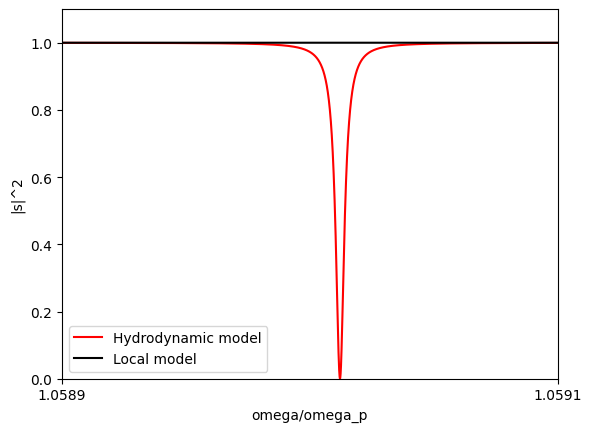

In [461]:
plt.plot(omegas, s_sqrds, color="red", label="Hydrodynamic model")
plt.plot(omegas, s_sqrds_local, color="black", label="Local model");
plt.xlim(omegas.min(), omegas.max())
plt.xticks([omegas.min(), omegas.max()])
plt.ylim(0, 1.1)
plt.ylabel("|s|^2")
plt.xlabel("omega/omega_p")
plt.legend();